# Dataset exploration - blended 2015 + 2019 fundus images

Exploratory pass over the data `train_eval.ipynb` actually trains on:
`data/raw/2019_2015_data`, which merges the EyePACS 2015 train+test sets with the
APTOS 2019 train set into a single `image,level` table.

Covered here: label coverage vs. the image files on disk, class balance overall and
per source year, sample images per severity grade, the Ben Graham preprocessing
compared against the plain resize, and the patient/eye structure of the 2015 half
that forces a grouped train/val split.

## Setup and paths

Same layout constants as the training notebook, so the two stay in sync.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

# Resolve the project root regardless of where the notebook is launched from.
project_root = Path.cwd()
if project_root.name in {"data", "model", "notebooks"}:
    project_root = project_root.parent

DATA_ROOT = project_root / "data" / "raw" / "2019_2015_data"
CSV_PATH = DATA_ROOT / "labels" / "traintestLabels15_trainLabels19.csv"

# Ben Graham preprocessed images are what training uses; the plain-resized copy is
# kept alongside for the before/after comparison further down.
IMAGE_DIR = DATA_ROOT / "resized_ben_graham"
RAW_IMAGE_DIR = DATA_ROOT / "resized_traintest15_train19"

for name, path in [("CSV", CSV_PATH), ("images", IMAGE_DIR), ("raw images", RAW_IMAGE_DIR)]:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {name} at {path}.\n"
            "Place the blended dataset under data/raw/2019_2015_data/ "
            "(labels/, resized_ben_graham/, resized_traintest15_train19/)."
        )

CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

# Severity is ordinal, so grades get one hue light -> dark rather than five
# unrelated colors. Source year (2015 vs 2019) is a plain category, so it gets two
# distinct hues. Text stays ink-colored; only the marks carry the encoding.
GRADE_COLORS = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]
SOURCE_COLORS = {2015: "#2a78d6", 2019: "#eb6834"}
INK, INK_MUTED = "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#d6d5d1",
    "axes.labelcolor": INK_MUTED,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "axes.grid": True,
    "grid.color": "#ebeae6",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
})

print(f"Project root: {project_root}")

Project root: e:\UMass\AI4ALL-19D


## Labels

The 2019 half is keyed by a hex `id_code` (one image per row, no patient link);
the 2015 half is keyed by `<patient>_<eye>`, so two rows share a patient. That
split in the ID format is the only thing separating the two sources, and the
training notebook keys off it too.

In [3]:
labels_df = pd.read_csv(CSV_PATH)

# 2015 IDs look like "10_left"; 2019 IDs are bare hex strings.
labels_df["is_2015"] = labels_df["image"].astype(str).str.contains("_")
labels_df["source"] = np.where(labels_df["is_2015"], 2015, 2019)
labels_df["patient_id"] = labels_df["image"].astype(str).str.split("_").str[0]
labels_df["eye"] = np.where(
    labels_df["is_2015"], labels_df["image"].astype(str).str.split("_").str[-1], "n/a"
)
labels_df["grade_name"] = labels_df["level"].map(dict(enumerate(CLASS_NAMES)))

print(f"Rows: {len(labels_df):,}")
print(labels_df["source"].value_counts().rename("images").to_frame())
labels_df.head()

Rows: 92,364
        images
source        
2015     88702
2019      3662


,image,level,is_2015,source,patient_id,eye,grade_name
0,10_left,0,True,2015,10,left,No DR
1,10_right,0,True,2015,10,right,No DR
2,13_left,0,True,2015,13,left,No DR
3,13_right,0,True,2015,13,right,No DR
4,15_left,1,True,2015,15,left,Mild


### Do the labels and the image files line up?

A missing file only surfaces as a `FileNotFoundError` deep inside a training epoch,
so check the whole join up front, in both image directories.

In [4]:
label_ids = set(labels_df["image"].astype(str))

for name, path in [("ben_graham", IMAGE_DIR), ("plain resize", RAW_IMAGE_DIR)]:
    file_ids = {p.stem for p in path.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}}
    missing = label_ids - file_ids
    extra = file_ids - label_ids
    print(f"{name:>13}: {len(file_ids):,} files | labelled-but-missing: {len(missing):,} "
          f"| unlabelled extras: {len(extra):,}")
    if missing:
        print(f"                 e.g. {sorted(missing)[:5]}")

   ben_graham: 92,364 files | labelled-but-missing: 0 | unlabelled extras: 0
 plain resize: 92,364 files | labelled-but-missing: 0 | unlabelled extras: 0


## Class balance

The headline problem with this dataset. Both sources are dominated by grade 0, and
2015 far more so than 2019 - which matters because 2015 contributes ~96% of the rows.

In [5]:
counts = labels_df["level"].value_counts().sort_index()
by_source = labels_df.pivot_table(index="level", columns="source", values="image", aggfunc="count").fillna(0).astype(int)

summary = pd.DataFrame({
    "grade": [CLASS_NAMES[i] for i in counts.index],
    "count": counts,
    "pct_of_all": (counts / counts.sum() * 100).round(2),
    "count_2015": by_source[2015],
    "pct_within_2015": (by_source[2015] / by_source[2015].sum() * 100).round(2),
    "count_2019": by_source[2019],
    "pct_within_2019": (by_source[2019] / by_source[2019].sum() * 100).round(2),
})
summary.index.name = "level"
print(f"Most common grade is {counts.idxmax()} at {counts.max() / counts.sum():.1%} of all images; "
      f"rarest is grade {counts.idxmin()} at {counts.min() / counts.sum():.1%} "
      f"({counts.max() / counts.min():.0f}x imbalance).")
summary

Most common grade is 0 at 72.7% of all images; rarest is grade 4 at 2.4% (30x imbalance).


,grade,count,pct_of_all,count_2015,pct_within_2015,count_2019,pct_within_2019
level,,,,,,,
0,No DR,67148,72.70,65343,73.67,1805,49.29
1,Mild,6575,7.12,6205,7.00,370,10.10
2,Moderate,14152,15.32,13153,14.83,999,27.28
3,Severe,2280,2.47,2087,2.35,193,5.27
4,Proliferative,2209,2.39,1914,2.16,295,8.06


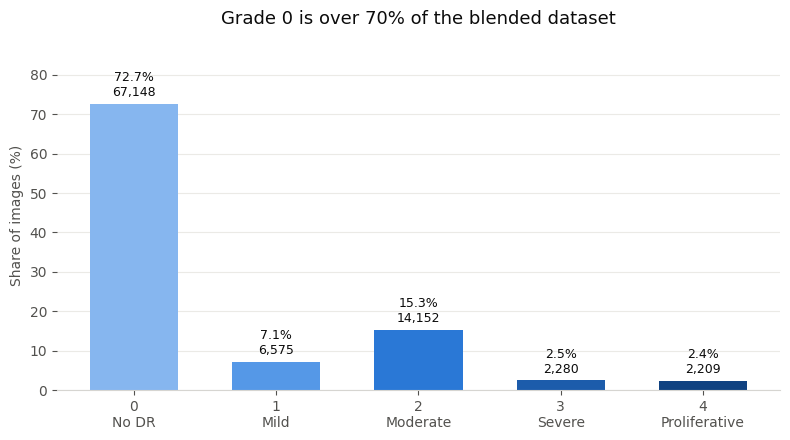

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))

pct = counts / counts.sum() * 100
bars = ax.bar(counts.index, pct, color=GRADE_COLORS, width=0.62)
for bar, n, p in zip(bars, counts.values, pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, p + 1.2, f"{p:.1f}%\n{n:,}",
            ha="center", va="bottom", fontsize=9, color=INK)

ax.set_title("Grade 0 is over 70% of the blended dataset", fontsize=13, color=INK, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Share of images (%)")
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels([f"{i}\n{name}" for i, name in enumerate(CLASS_NAMES)])
ax.set_ylim(0, pct.max() * 1.22)
ax.grid(axis="x", visible=False)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

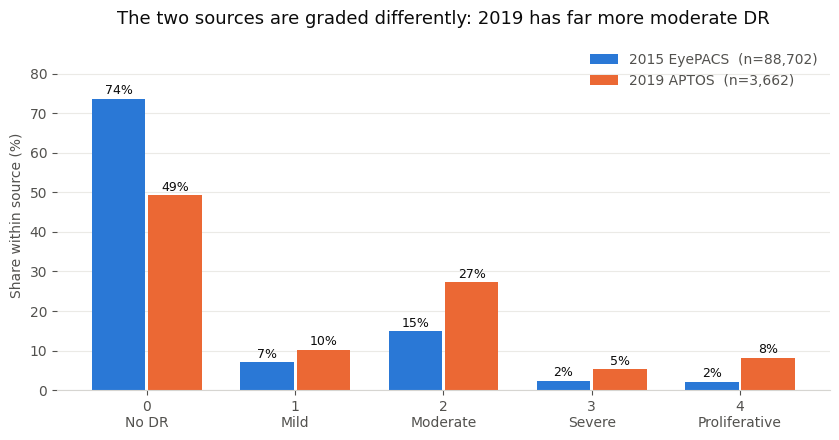

In [7]:
# Percentages within each source, not raw counts: 2015 outnumbers 2019 ~25:1, so
# raw counts would just redraw the 2015 bars.
pct_2015 = by_source[2015] / by_source[2015].sum() * 100
pct_2019 = by_source[2019] / by_source[2019].sum() * 100

fig, ax = plt.subplots(figsize=(8.5, 4.5))
x = np.arange(len(CLASS_NAMES))
w = 0.36
ax.bar(x - w / 2 - 0.01, pct_2015, width=w, color=SOURCE_COLORS[2015],
       label=f"2015 EyePACS  (n={by_source[2015].sum():,})")
ax.bar(x + w / 2 + 0.01, pct_2019, width=w, color=SOURCE_COLORS[2019],
       label=f"2019 APTOS  (n={by_source[2019].sum():,})")

for xi, (a, b) in enumerate(zip(pct_2015, pct_2019)):
    ax.text(xi - w / 2 - 0.01, a + 1.2, f"{a:.0f}%", ha="center", fontsize=9, color=INK)
    ax.text(xi + w / 2 + 0.01, b + 1.2, f"{b:.0f}%", ha="center", fontsize=9, color=INK)

ax.set_title("The two sources are graded differently: 2019 has far more moderate DR",
             fontsize=13, color=INK, pad=12)
ax.set_ylabel("Share within source (%)")
ax.set_xticks(x)
ax.set_xticklabels([f"{i}\n{name}" for i, name in enumerate(CLASS_NAMES)])
ax.set_ylim(0, max(pct_2015.max(), pct_2019.max()) * 1.2)
ax.grid(axis="x", visible=False)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, loc="upper right", labelcolor=INK_MUTED)
plt.tight_layout()
plt.show()

## Sample images by grade

One row per severity grade, drawn from the preprocessed directory that training
reads. Grade 0 fundi look clean; higher grades add hemorrhages, exudates and
neovascularization - the subtle grade 1 vs. grade 2 boundary is where most of the
model's confusion lands.

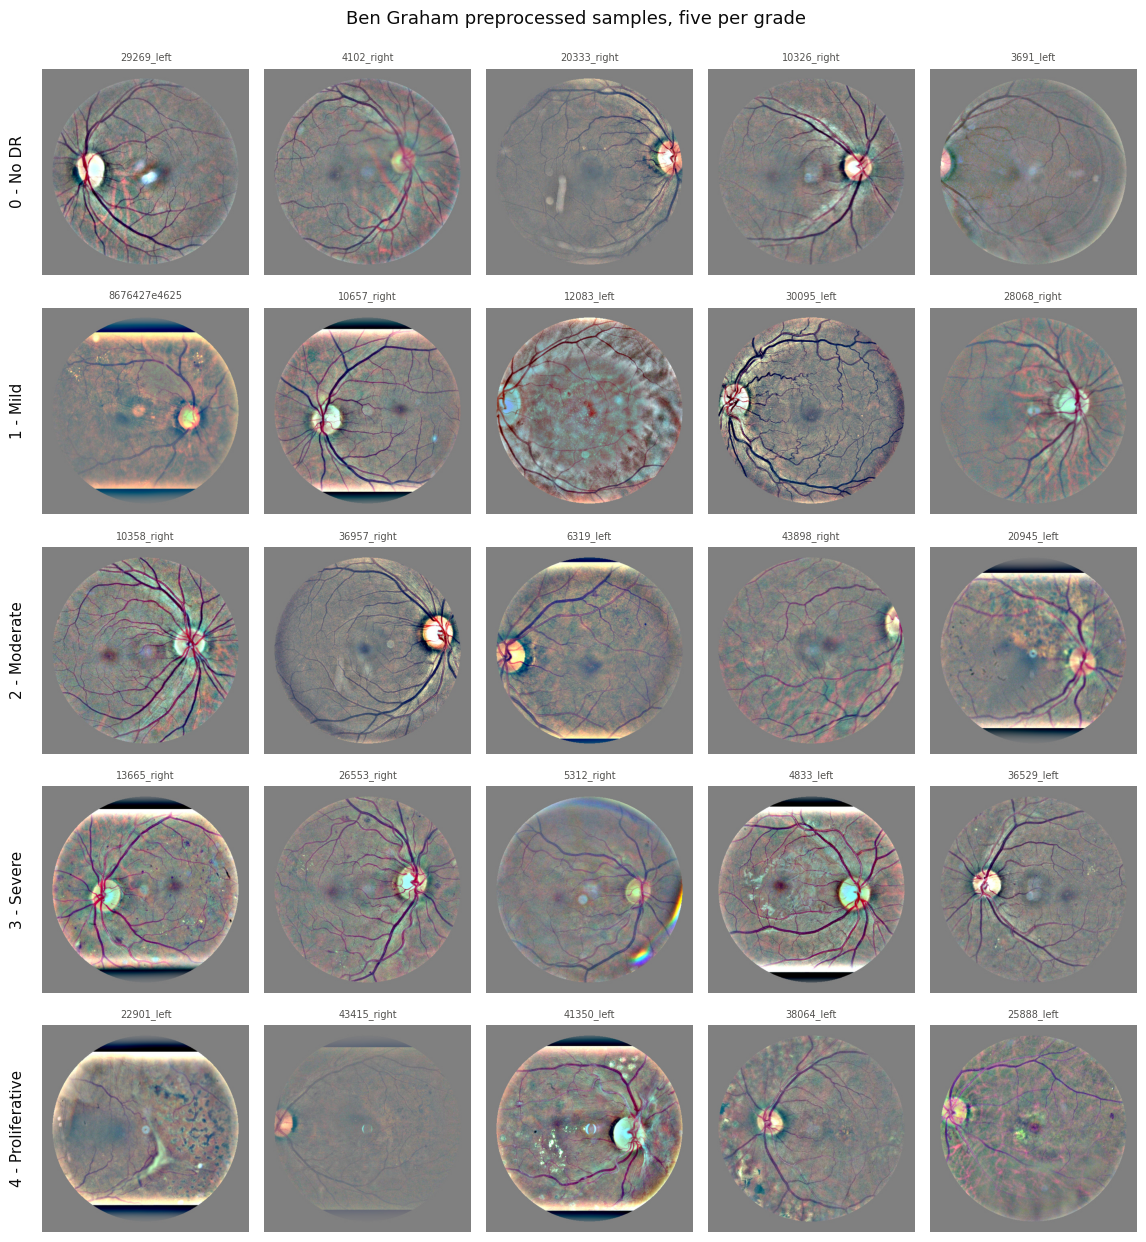

In [8]:
SAMPLES_PER_GRADE = 5
rng = np.random.default_rng(42)

fig, axes = plt.subplots(len(CLASS_NAMES), SAMPLES_PER_GRADE,
                         figsize=(2.3 * SAMPLES_PER_GRADE, 2.5 * len(CLASS_NAMES)))
for level, row_axes in zip(range(len(CLASS_NAMES)), axes):
    pool = labels_df.loc[labels_df["level"] == level, "image"].astype(str).values
    picks = rng.choice(pool, size=min(SAMPLES_PER_GRADE, len(pool)), replace=False)
    for ax, img_id in zip(row_axes, picks):
        ax.imshow(Image.open(IMAGE_DIR / f"{img_id}.jpg"))
        ax.set_title(img_id, fontsize=7, color=INK_MUTED)
        ax.axis("off")
    for ax in row_axes[len(picks):]:
        ax.axis("off")
    row_axes[0].set_ylabel("")
    # Label the row on the left edge, in ink rather than the grade color.
    row_axes[0].text(-0.12, 0.5, f"{level} - {CLASS_NAMES[level]}", rotation=90,
                     transform=row_axes[0].transAxes, ha="center", va="center",
                     fontsize=11, color=INK)

fig.suptitle("Ben Graham preprocessed samples, five per grade", fontsize=13, color=INK, y=0.995)
plt.tight_layout()
plt.show()

## Preprocessing: plain resize vs. Ben Graham

`preprocess_ben_graham.py` crops the black border, rescales each eye to a common
radius, then subtracts a heavy Gaussian blur. That flattens the wildly varying
illumination and camera color casts across the two source datasets and pushes
lesion contrast up, which is why training points `IMAGE_DIR` at the processed copy.

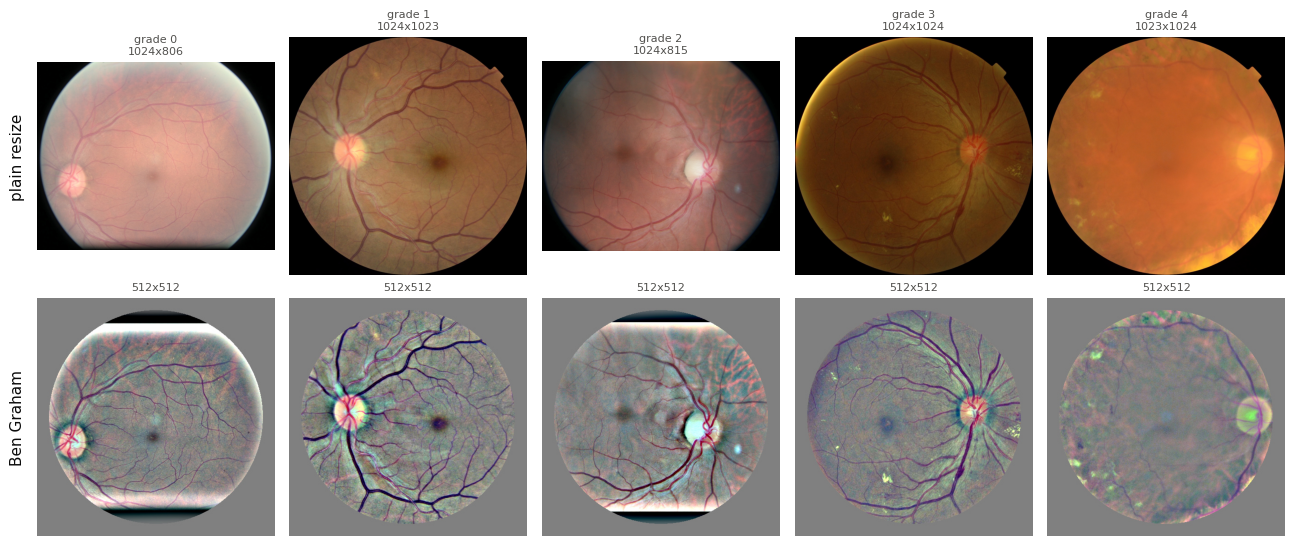

In [9]:
# One image per grade, same IDs in both directories.
compare_ids = [
    labels_df.loc[labels_df["level"] == lv, "image"].astype(str).sample(1, random_state=7).item()
    for lv in range(len(CLASS_NAMES))
]

fig, axes = plt.subplots(2, len(compare_ids), figsize=(2.6 * len(compare_ids), 5.6))
for col, img_id in enumerate(compare_ids):
    raw_img = Image.open(RAW_IMAGE_DIR / f"{img_id}.jpg")
    proc_img = Image.open(IMAGE_DIR / f"{img_id}.jpg")
    axes[0, col].imshow(raw_img)
    axes[0, col].set_title(f"grade {labels_df.loc[labels_df['image'] == img_id, 'level'].item()}"
                           f"\n{raw_img.size[0]}x{raw_img.size[1]}", fontsize=8, color=INK_MUTED)
    axes[1, col].imshow(proc_img)
    axes[1, col].set_title(f"{proc_img.size[0]}x{proc_img.size[1]}", fontsize=8, color=INK_MUTED)
    for r in (0, 1):
        axes[r, col].axis("off")

axes[0, 0].text(-0.08, 0.5, "plain resize", rotation=90, transform=axes[0, 0].transAxes,
                ha="center", va="center", fontsize=11, color=INK)
axes[1, 0].text(-0.08, 0.5, "Ben Graham", rotation=90, transform=axes[1, 0].transAxes,
                ha="center", va="center", fontsize=11, color=INK)
plt.tight_layout()
plt.show()

In [10]:
# Image geometry, on a sample: the processed set is uniformly square, the plain
# resize is not - which is why the val transform resizes then center-crops instead
# of squashing to a fixed (H, W).
sample_ids = labels_df["image"].astype(str).sample(200, random_state=0)
geom = pd.DataFrame({
    "ben_graham": [Image.open(IMAGE_DIR / f"{i}.jpg").size for i in sample_ids],
    "plain_resize": [Image.open(RAW_IMAGE_DIR / f"{i}.jpg").size for i in sample_ids],
})
for col in geom.columns:
    sizes = geom[col].value_counts()
    ratios = np.array([w / h for w, h in geom[col]])
    print(f"{col:>13}: {len(sizes)} distinct sizes | most common {sizes.index[0]} "
          f"({sizes.iloc[0]}/{len(geom)}) | aspect ratio {ratios.min():.2f}-{ratios.max():.2f}")

   ben_graham: 1 distinct sizes | most common (512, 512) (200/200) | aspect ratio 1.00-1.00
 plain_resize: 86 distinct sizes | most common (1024, 1022) (14/200) | aspect ratio 1.00-1.42


## Patient structure in the 2015 half

Each 2015 patient contributes a left and a right eye. Both eyes of one patient are
near-duplicates from the same camera session, so a random image-level split would
leak: the model could memorize a patient in training and be scored on their other
eye in validation. `build_splits()` in `train_eval.ipynb` handles this with a
`GroupShuffleSplit` on `patient_id`; the 2019 half has no patient link and gets a
plain stratified split.

In [11]:
df_2015 = labels_df[labels_df["is_2015"]]
eyes_per_patient = df_2015.groupby("patient_id").size()

print(f"2015 patients: {eyes_per_patient.size:,} | images: {len(df_2015):,}")
print(f"Eyes per patient: {eyes_per_patient.value_counts().sort_index().to_dict()}")

paired = df_2015.pivot_table(index="patient_id", columns="eye", values="level", aggfunc="first").dropna()
agree = (paired["left"] == paired["right"]).mean()
within_one = ((paired["left"] - paired["right"]).abs() <= 1).mean()
print(f"\nOf {len(paired):,} two-eye patients: {agree:.1%} have identical grades in both eyes, "
      f"{within_one:.1%} are within one grade.")
print("-> the two eyes of a patient are highly correlated; splitting them across "
      "train/val would inflate validation scores.")

2015 patients: 44,351 | images: 88,702
Eyes per patient: {2: 44351}

Of 44,351 two-eye patients: 87.5% have identical grades in both eyes, 95.8% are within one grade.
-> the two eyes of a patient are highly correlated; splitting them across train/val would inflate validation scores.


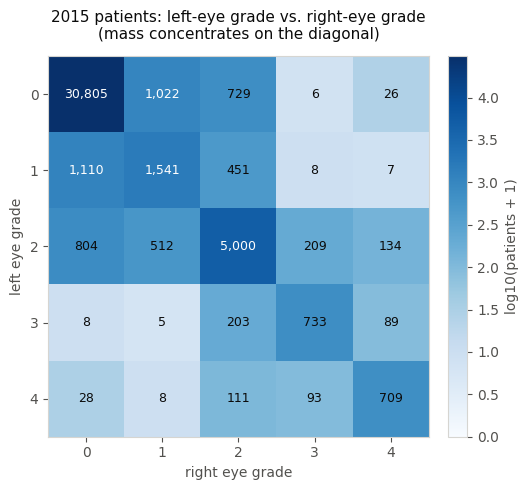

In [12]:
# Where the correlated pairs sit: a joint count of (left grade, right grade).
joint = pd.crosstab(paired["left"].astype(int), paired["right"].astype(int))
joint = joint.reindex(index=range(5), columns=range(5), fill_value=0)

fig, ax = plt.subplots(figsize=(5.8, 5))
# Log scale on the sequential ramp - the 0/0 cell is ~3 orders of magnitude above
# the rest and would flatten every other cell to white on a linear scale.
im = ax.imshow(np.log10(joint.values + 1), cmap="Blues", vmin=0)
for i in range(5):
    for j in range(5):
        v = joint.values[i, j]
        ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=9,
                color="white" if np.log10(v + 1) > 0.65 * np.log10(joint.values.max() + 1) else INK)

ax.set_title("2015 patients: left-eye grade vs. right-eye grade\n(mass concentrates on the diagonal)",
             fontsize=11, color=INK, pad=12)
ax.set_xlabel("right eye grade")
ax.set_ylabel("left eye grade")
ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.grid(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("log10(patients + 1)", color=INK_MUTED)
plt.tight_layout()
plt.show()

## Takeaways for training

- **~92k images, ~96% of them from 2015.** Any modelling decision is effectively a
  decision about the 2015 distribution.
- **Grade 0 is >70% of the data and grade 4 under 3%.** Plain accuracy is
  meaningless here - macro F1 and quadratic-weighted kappa are the metrics
  `train_eval.ipynb` reports, and it counters the imbalance with a
  `WeightedRandomSampler` plus 2015 grade-0 downsampling.
- **The two sources are graded differently**, so validation is reported split by
  source in the confusion-matrix cell.
- **2015 rows are paired by patient**, which requires a grouped split; the demo
  holdout set is also carved out by patient family before any splitting.
- **The Ben Graham copy is uniformly 512x512**, so the transforms can crop rather
  than squash.